# Imports

In [1]:
from pygsp import filters, graphs
import numpy as np
import matplotlib.pyplot as plt

# Problem 1

## Creating graph

In [2]:
G = graphs.Sensor(N = 100, seed = 1)

2026-04-21 01:18:43,577:[DEBUG](pygsp.graphs.nngraphs.nngraph.__init__): Using scipy KDTree for k-NN search


## Calculating fourier analysis

In [3]:
G.compute_fourier_basis()

In [4]:
G.U

array([[ 1.00000000e-01,  1.49545919e-01,  3.50570171e-02, ...,
         1.02491267e-03,  9.43121313e-05,  1.11622388e-02],
       [ 1.00000000e-01,  1.48379556e-01, -4.48058532e-02, ...,
        -4.57806271e-03, -6.41481308e-06, -2.54012736e-04],
       [ 1.00000000e-01, -3.86032525e-02, -1.21446563e-01, ...,
        -1.95205946e-03,  2.25385510e-04, -7.23546522e-04],
       ...,
       [ 1.00000000e-01, -2.40371296e-02, -1.54592941e-01, ...,
         1.00706374e-03, -8.86104019e-06,  2.43127544e-04],
       [ 1.00000000e-01, -3.32603836e-02, -1.18990155e-01, ...,
        -4.79732899e-03, -4.00782957e-04, -2.06648540e-03],
       [ 1.00000000e-01, -6.85985441e-02, -1.50321873e-01, ...,
         3.06284576e-05,  6.04296095e-05,  5.90155445e-06]],
      shape=(100, 100))

In [5]:
G.N

100

## Graph signals and GFT

In [6]:
random_signal = np.random.randn(G.N)

heat0 = filters.Heat(G, scale = 0)
heat10 = filters.Heat(G, scale = 10)

x1 = heat0.filter(random_signal).squeeze()
x2 = heat10.filter(random_signal).squeeze()

x1hat = G.gft(x1).squeeze()
x2hat = G.gft(x2).squeeze()

## Smoothness

In [7]:
S1 = x1.T @ G.L @ x1
print(f'The smoothness of the Heat filter with tau = 0 is {S1:.4f}')

S2 = x2.T @ G.L @ x2
print(f'The smoothness of the Heat filter with tau = 10 is {S2:.4f}')

The smoothness of the Heat filter with tau = 0 is 509.1000
The smoothness of the Heat filter with tau = 10 is 0.9988


## Plotting

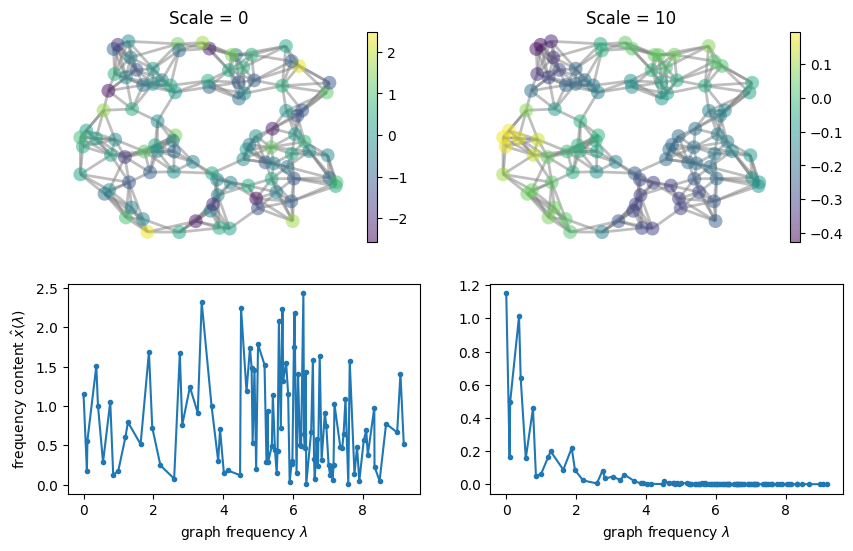

In [8]:
fig, axs = plt.subplots(2, 2 ,figsize = (10, 6))
G.plot(x1, ax = axs[0, 0])
axs[0, 0].set_axis_off()
axs[0, 0].set_title("Scale = 0")
axs[1, 0].plot(G.e, np.abs(x1hat), ".-")
axs[1, 0].set_xlabel(r"graph frequency $\lambda$")
axs[1, 0].set_ylabel(r"frequency content $\hat{x}(\lambda)$")

G.plot(x2, ax = axs[0, 1])
axs[0, 1].set_axis_off()
axs[0, 1].set_title("Scale = 10")
axs[1, 1].plot(G.e, np.abs(x2hat), ".-")
axs[1, 1].set_xlabel(r"graph frequency $\lambda$")
plt.show()

# Problem 2

## Generating graphs

In [ ]:
from torch_geometric.datasets import Planetoid
dataset = Planetoid(root='./data/Cora', name='Cora')
Cora = dataset[0]

c:\Users\djd14\miniconda3\envs\eel6878torch\Lib\site-packages\pygsp\graphs\graph.py:619: FutureWarning: Input has data type int64, but the output has been cast to float64.  In the future, the output data type will match the input. To avoid this warning, set the `dtype` parameter to `None` to have the output dtype match the input, or set it to the desired output data type.
  D = sparse.diags(self.dw)
Processing...
c:\Users\djd14\miniconda3\envs\eel6878torch\Lib\site-packages\torch_geometric\io\planetoid.py:107: VisibleDeprecationWarning: dtype(): align should be passed as Python or NumPy boolean but got `align=0`. Did you mean to pass a tuple to create a subarray type? (Deprecated NumPy 2.4)
  out = pickle.load(f, encoding='latin1')
c:\Users\djd14\miniconda3\envs\eel6878torch\Lib\site-packages\torch_geometric\io\planetoid.py:107: VisibleDeprecationWarning: dtype(): align should be passed as Python or NumPy boolean but got `align=0`. Did you mean to pass a tuple to create a subarray type

In [16]:
from torch_geometric.utils import to_networkx
from torch_geometric.utils import to_scipy_sparse_matrix
ER = graphs.ErdosRenyi(N = 50, p = 0.1)
Ring = graphs.Ring(N = 50)
G_cora = to_networkx(Cora, to_undirected=True)
A = to_scipy_sparse_matrix(Cora.edge_index, num_nodes=Cora.num_nodes)

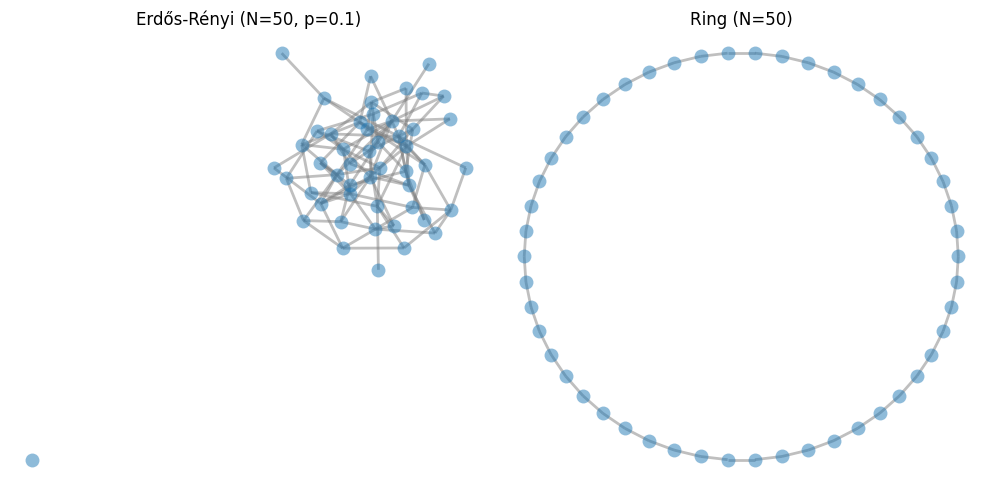

In [29]:
ER.set_coordinates('spring')
Ring.set_coordinates('ring2D')
fig, axs = plt.subplots(1, 2, figsize=(10, 5))
ER.plot(ax=axs[0], title='Erdős-Rényi (N=50, p=0.1)')
axs[0].set_axis_off()
Ring.plot(ax=axs[1], title='Ring (N=50)')
axs[1].set_axis_off()
plt.tight_layout()
plt.show()